# SVT Analysis
Notebook for quick SVT experiments and visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = Path(PROJECT_ROOT) / "data" / "CBSD68"
RESULTS_PATH = Path(PROJECT_ROOT) / "results" / "svt" / "images"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.svt.svt import svt
from src.utils.masking import create_mask, apply_mask
from src.utils.noise import add_gaussian_noise
from src.utils.io import load_image
from src.utils.metrics import mse, psnr

from experiments.config import *

In [2]:
rec = pd.read_csv(RESULTS_PATH / "reconstruction.csv")
den = pd.read_csv(RESULTS_PATH / "denoising.csv")

In [30]:
rec_avg = rec.groupby("sparsity")["PSNR"].mean()
den_avg = den.groupby("sigma")["PSNR"].mean()

print("Reconstruction PSNR vs. Observed Fraction:", rec_avg)
print("Denoising PSNR vs. Noise Level:", den_avg)

Reconstruction PSNR vs. Observed Fraction: sparsity
0.2    19.965647
0.4    21.833601
0.6    22.009868
Name: PSNR, dtype: float64
Denoising PSNR vs. Noise Level: sigma
0.05    22.078218
0.10    21.912195
0.20    20.858750
Name: PSNR, dtype: float64


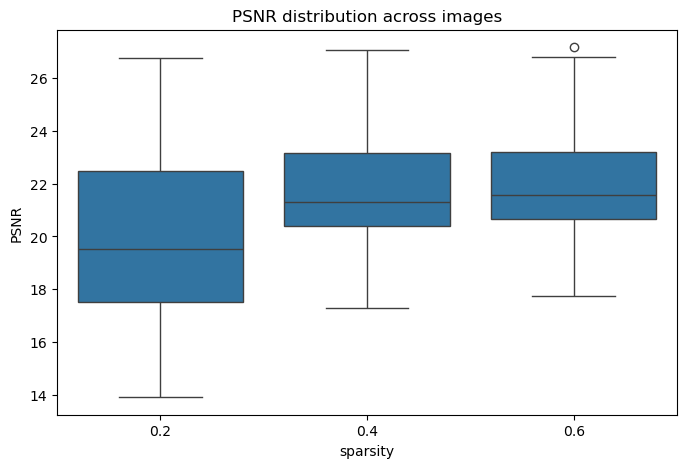

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=rec, x="sparsity", y="PSNR")
plt.title("PSNR distribution across images")
plt.show()

In [3]:
def show_results(X, X_rec, X_noisy=None, title=""):
    plt.figure(figsize=(12, 4))

    if X_noisy is not None:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap='gray')
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_noisy, cmap='gray')
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap='gray')
        plt.title("Denoised")
        plt.axis("off")

    else:
        plt.subplot(1, 2, 1)
        plt.imshow(X, cmap='gray')
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(X_rec, cmap='gray')
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

iter 0, rank 1, residual 0.62713
iter 1, rank 1, residual 0.37254
iter 2, rank 1, residual 0.34581
iter 3, rank 1, residual 0.34307
iter 4, rank 1, residual 0.34224
iter 5, rank 1, residual 0.34162
iter 6, rank 1, residual 0.34106
iter 7, rank 1, residual 0.34056
iter 8, rank 1, residual 0.34010
iter 9, rank 1, residual 0.33969
iter 10, rank 1, residual 0.33931
iter 11, rank 1, residual 0.33897
iter 12, rank 1, residual 0.33865
iter 13, rank 1, residual 0.33837
iter 14, rank 1, residual 0.33812
iter 15, rank 1, residual 0.33788
iter 16, rank 1, residual 0.33767
iter 17, rank 1, residual 0.33748
iter 18, rank 1, residual 0.33730
iter 19, rank 1, residual 0.33714
iter 20, rank 1, residual 0.33700
iter 21, rank 1, residual 0.33687
iter 22, rank 1, residual 0.33675
iter 23, rank 1, residual 0.33664
iter 24, rank 1, residual 0.33654
iter 25, rank 1, residual 0.33645
iter 26, rank 1, residual 0.33637
iter 27, rank 1, residual 0.33630
iter 28, rank 1, residual 0.33623
iter 29, rank 1, residua

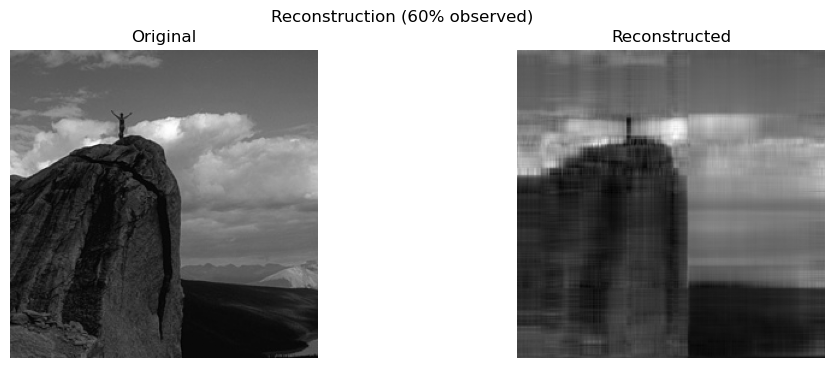

In [11]:
# Reconstruction
X = load_image(DATA_PATH / "0002.png")
X = X[:256, :256]
n1, n2 = X.shape
observed_fraction = 0.6
tau = TAU_FACTOR * max(n1, n2)
delta = DELTA_FACTOR
mask = create_mask(X.shape, observed_fraction, seed=SEED)
Omega, b = apply_mask(X, mask)

X_rec, hist = svt(X.shape, Omega, b, tau, delta)

print("MSE:", mse(X, X_rec))
print("PSNR:", psnr(X, X_rec))

show_results(X, X_rec, title="Reconstruction (60% observed)")

Text(0.5, 1.0, 'Image singular value decay')

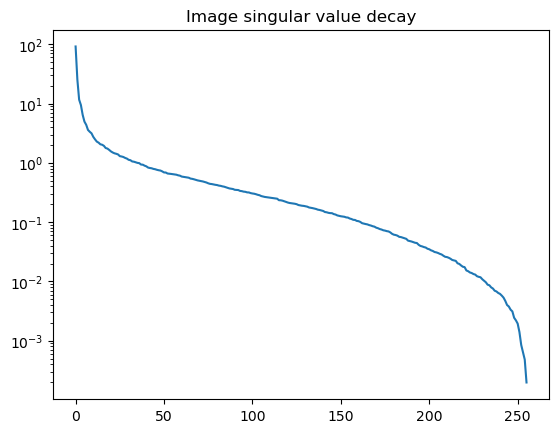

In [6]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)

plt.semilogy(S)
plt.title("Image singular value decay")

iter 0, rank 1, residual 0.61500
iter 1, rank 1, residual 0.41010
iter 2, rank 1, residual 0.39973
iter 3, rank 1, residual 0.39931
iter 4, rank 1, residual 0.39929
iter 5, rank 1, residual 0.39929
iter 6, rank 1, residual 0.39929
iter 7, rank 1, residual 0.39929
iter 8, rank 1, residual 0.39929
iter 9, rank 1, residual 0.39929
iter 10, rank 1, residual 0.39929
iter 11, rank 1, residual 0.39929
iter 12, rank 1, residual 0.39929
iter 13, rank 1, residual 0.39929
iter 14, rank 1, residual 0.39929
iter 15, rank 1, residual 0.39929
iter 16, rank 1, residual 0.39929
iter 17, rank 1, residual 0.39929
iter 18, rank 1, residual 0.39929
iter 19, rank 1, residual 0.39929
iter 20, rank 1, residual 0.39929
iter 21, rank 1, residual 0.39929
iter 22, rank 1, residual 0.39929
iter 23, rank 1, residual 0.39929
iter 24, rank 1, residual 0.39929
iter 25, rank 1, residual 0.39929
iter 26, rank 1, residual 0.39929
iter 27, rank 1, residual 0.39929
iter 28, rank 1, residual 0.39929
iter 29, rank 1, residua

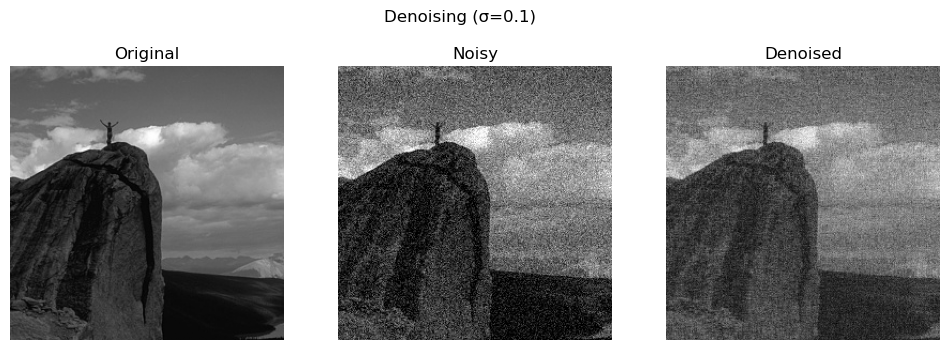

In [10]:
# Denoising
X_noisy = add_gaussian_noise(X, sigma=0.1)

n1, n2 = X.shape
tau = TAU_FACTOR * max(n1, n2)
delta = DELTA_FACTOR

Omega = np.where(np.ones_like(X, dtype=bool))
b = X_noisy[Omega]

X_denoised, _ = svt(X.shape, Omega, b, tau, delta)

print("MSE:", mse(X, X_denoised))
print("PSNR:", psnr(X, X_denoised))

show_results(X, X_denoised, X_noisy, title="Denoising (σ=0.1)")